# Sketch to Structured Visual Data and Re-draw Code
Notebook ini mengubah hasil sketsa menjadi data visual terstruktur dan kode untuk menggambar ulang:
- Contour / titik koordinat `(x, y)` (JSON)
- Edge map (`.npy` dan `.png`)
- Vector path SVG (`.svg`)
- Kode Python (matplotlib/OpenCV)
- Kode Python turtle
- Kode HTML/CSS/JS (SVG path)

In [1]:
# Jika belum ada, jalankan sekali:
# %pip install opencv-python numpy matplotlib

In [2]:
from pathlib import Path
import json

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Input sketch dari langkah sebelumnya
input_sketch = Path('image/output/result_sketch.png')
if not input_sketch.exists():
    raise FileNotFoundError(
        f'Tidak menemukan file {input_sketch}. Jalankan notebook opencv_sketch_cartoon.ipynb dulu.'
    )

out_dir = Path('image/output/structured')
out_dir.mkdir(parents=True, exist_ok=True)

code_dir = Path('generated_code')
code_dir.mkdir(parents=True, exist_ok=True)

sketch_gray = cv2.imread(str(input_sketch), cv2.IMREAD_GRAYSCALE)
if sketch_gray is None:
    raise ValueError('Gagal membaca gambar sketsa')

h, w = sketch_gray.shape
print('Input:', input_sketch)
print('Ukuran:', (h, w))

Input: image/output/result_sketch.png
Ukuran: (255, 163)


In [19]:
# 1) Edge map (array NumPy + gambar)
# Blur ringan + Canny threshold lebih lembut agar garis tipis tetap tertangkap.
blurred = cv2.GaussianBlur(sketch_gray, (3, 3), 0)
edge_map = cv2.Canny(blurred, 35, 110)
np.save(out_dir / 'edge_map.npy', edge_map)
cv2.imwrite(str(out_dir / 'edge_map.png'), edge_map)

# Biner untuk ekstraksi kontur.
_, binary_inv = cv2.threshold(blurred, 208, 255, cv2.THRESH_BINARY_INV)

# Tutup gap kecil antarpiksel agar stroke tidak putus.
kernel = np.ones((2, 2), np.uint8)
binary_inv = cv2.morphologyEx(binary_inv, cv2.MORPH_CLOSE, kernel, iterations=1)


def skeletonize(binary_img: np.ndarray) -> np.ndarray:
    """Morphological skeletonization: menghasilkan centerline 1-pixel."""
    img = binary_img.copy()
    skel = np.zeros_like(img)
    k = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

    while True:
        eroded = cv2.erode(img, k)
        opened = cv2.dilate(eroded, k)
        temp = cv2.subtract(img, opened)
        skel = cv2.bitwise_or(skel, temp)
        img = eroded

        if cv2.countNonZero(img) == 0:
            break

    return skel


skeleton = skeletonize(binary_inv)
cv2.imwrite(str(out_dir / 'binary_for_contours.png'), binary_inv)
cv2.imwrite(str(out_dir / 'skeleton_centerline.png'), skeleton)

print('Tersimpan edge map, binary image, dan skeleton centerline untuk contour')

Tersimpan edge map, binary image, dan skeleton centerline untuk contour


In [20]:
# 2) Contour / titik koordinat (x, y)
# Ambil kontur dari skeleton agar mengikuti centerline garis (lebih mirip sketsa asli).
raw_contours, _ = cv2.findContours(skeleton, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)


def smooth_polyline(points_xy: np.ndarray, window: int = 3, passes: int = 1) -> np.ndarray:
    """Smoothing ringan agar tidak bergerigi tanpa mengubah bentuk signifikan."""
    if len(points_xy) < window:
        return points_xy.astype(np.float32)

    out = points_xy.astype(np.float32)
    kernel = np.ones(window, dtype=np.float32) / float(window)
    pad = window // 2

    for _ in range(passes):
        x_pad = np.pad(out[:, 0], (pad, pad), mode='edge')
        y_pad = np.pad(out[:, 1], (pad, pad), mode='edge')
        x = np.convolve(x_pad, kernel, mode='valid')
        y = np.convolve(y_pad, kernel, mode='valid')
        out = np.column_stack([x, y])

    return out


contours_xy = []
for cnt in raw_contours:
    if len(cnt) < 8:
        continue

    perimeter = cv2.arcLength(cnt, closed=False)
    if perimeter < 12:
        continue

    points_xy = cnt[:, 0, :]
    smoothed = smooth_polyline(points_xy, window=3, passes=1)

    # Epsilon sangat kecil agar detail tetap terjaga.
    epsilon = max(0.12, 0.00035 * perimeter)
    approx = cv2.approxPolyDP(smoothed.reshape(-1, 1, 2), epsilon, closed=False)
    points = [[int(p[0][0]), int(p[0][1])] for p in approx]

    dedup_points = []
    for x, y in points:
        if not dedup_points or dedup_points[-1] != [x, y]:
            dedup_points.append([x, y])

    if len(dedup_points) >= 2:
        contours_xy.append(dedup_points)

# Prioritaskan kontur panjang agar garis utama digambar dulu.
contours_xy.sort(key=lambda c: len(c), reverse=True)

contours_payload = {
    'source_image': str(input_sketch),
    'width': int(w),
    'height': int(h),
    'contours': contours_xy,
}

contours_json_path = out_dir / 'contours_xy.json'
with open(contours_json_path, 'w', encoding='utf-8') as f:
    json.dump(contours_payload, f, indent=2)

print(f'Jumlah contour tersimpan: {len(contours_xy)}')
print('File:', contours_json_path)

Jumlah contour tersimpan: 38
File: image/output/structured/contours_xy.json


In [17]:
# 3) Vector path (SVG)
def contour_to_svg_path(points):
    if len(points) < 2:
        return ''

    # Quadratic bezier path: lebih halus dari polyline lurus penuh.
    if len(points) == 2:
        (x0, y0), (x1, y1) = points
        return f'M {x0:.2f} {y0:.2f} L {x1:.2f} {y1:.2f}'

    cmds = []
    x0, y0 = points[0]
    cmds.append(f'M {x0:.2f} {y0:.2f}')

    for i in range(1, len(points) - 1):
        x_prev, y_prev = points[i]
        x_next, y_next = points[i + 1]
        mx = (x_prev + x_next) / 2.0
        my = (y_prev + y_next) / 2.0
        cmds.append(f'Q {x_prev:.2f} {y_prev:.2f} {mx:.2f} {my:.2f}')

    x_last, y_last = points[-1]
    x_before, y_before = points[-2]
    cmds.append(f'Q {x_before:.2f} {y_before:.2f} {x_last:.2f} {y_last:.2f}')

    return ' '.join(cmds)


svg_paths = [contour_to_svg_path(c) for c in contours_xy if len(c) >= 2]
svg_paths = [p for p in svg_paths if p]

svg_lines = [
    f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 {w} {h}" width="{w}" height="{h}">',
    '<rect width="100%" height="100%" fill="white" />',
]
for d in svg_paths:
    svg_lines.append(
        f'<path d="{d}" fill="none" stroke="black" stroke-width="1" stroke-linecap="round" stroke-linejoin="round" />'
    )
svg_lines.append('</svg>')

svg_path = out_dir / 'sketch_paths.svg'
svg_path.write_text('\n'.join(svg_lines), encoding='utf-8')

paths_json_path = out_dir / 'svg_paths.json'
with open(paths_json_path, 'w', encoding='utf-8') as f:
    json.dump({'width': w, 'height': h, 'paths': svg_paths}, f, indent=2)

print('File SVG:', svg_path)
print('File path list:', paths_json_path)

File SVG: image/output/structured/sketch_paths.svg
File path list: image/output/structured/svg_paths.json


In [ ]:
# 4) Generate kode Python matplotlib/OpenCV untuk redraw garis
matplot_cv_code = '''from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np

DATA_PATH = Path("image/output/structured/contours_xy.json")
OUT_IMG = Path("image/output/structured/redraw_opencv.png")

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

w = int(data["width"])
h = int(data["height"])
contours = data["contours"]


def is_closed_path(points, tol=2.5):
    if len(points) < 3:
        return False
    x0, y0 = points[0]
    x1, y1 = points[-1]
    return ((x0 - x1) ** 2 + (y0 - y1) ** 2) ** 0.5 <= tol


# Redraw dengan OpenCV pada kanvas putih
canvas = np.full((h, w, 3), 255, dtype=np.uint8)
for c in contours:
    pts = np.array(c, dtype=np.int32).reshape(-1, 1, 2)
    closed = is_closed_path(c)
    cv2.polylines(
        canvas,
        [pts],
        isClosed=closed,
        color=(0, 0, 0),
        thickness=1,
        lineType=cv2.LINE_AA,
    )

cv2.imwrite(str(OUT_IMG), canvas)
print(f"Saved OpenCV redraw: {OUT_IMG}")

# Plot garis dengan matplotlib (koordinat gambar: y ke bawah)
plt.figure(figsize=(6, 8))
for c in contours:
    arr = np.array(c)
    plt.plot(arr[:, 0], arr[:, 1], color="black", linewidth=0.65)

plt.gca().invert_yaxis()
plt.gca().set_aspect("equal", adjustable="box")
plt.axis("off")
plt.title("Re-draw from Contours")
plt.tight_layout()
plt.show()
'''

(code_dir / 'redraw_with_matplotlib_opencv.py').write_text(matplot_cv_code, encoding='utf-8')
print('Generated:', code_dir / 'redraw_with_matplotlib_opencv.py')

Generated: generated_code/redraw_with_matplotlib_opencv.py


In [8]:
# 5) Generate kode Python turtle untuk redraw dari titik kontur
turtle_code = '''from pathlib import Path
import json
import turtle

DATA_PATH = Path("image/output/structured/contours_xy.json")

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

w = int(data["width"])
h = int(data["height"])
contours = data["contours"]

screen = turtle.Screen()
screen.setup(width=min(1200, w + 120), height=min(900, h + 120))
screen.title("Turtle Re-draw from Contours")

pen = turtle.Turtle()
pen.hideturtle()
pen.speed(0)
pen.pensize(1)
pen.color("black")

def to_turtle_coords(x, y):
    tx = x - (w / 2)
    ty = (h / 2) - y
    return tx, ty

max_contours = 600  # Batasi agar performa tetap responsif
for contour in contours[:max_contours]:
    if len(contour) < 2:
        continue

    x0, y0 = contour[0]
    pen.penup()
    pen.goto(*to_turtle_coords(x0, y0))
    pen.pendown()

    for x, y in contour[1:]:
        pen.goto(*to_turtle_coords(x, y))

screen.mainloop()
'''

(code_dir / 'redraw_with_turtle.py').write_text(turtle_code, encoding='utf-8')
print('Generated:', code_dir / 'redraw_with_turtle.py')

Generated: generated_code/redraw_with_turtle.py


In [14]:
# 6) Generate HTML/CSS/JS untuk render SVG path di browser
html_code = '''<!doctype html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>Sketch SVG Paths</title>
  <style>
    :root {
      --bg: #f6f4ef;
      --ink: #1b1b1b;
      --card: #fffdf8;
    }
    body {
      margin: 0;
      background: radial-gradient(circle at 20% 10%, #fff9e8 0%, var(--bg) 40%, #ece7da 100%);
      color: var(--ink);
      font-family: Georgia, "Times New Roman", serif;
      min-height: 100vh;
      display: grid;
      place-items: center;
      padding: 20px;
    }
    .wrap {
      width: min(900px, 95vw);
      background: var(--card);
      border: 1px solid #dad2bf;
      border-radius: 16px;
      box-shadow: 0 15px 45px rgba(0, 0, 0, 0.12);
      padding: 18px;
    }
    h1 {
      margin: 0 0 12px;
      font-size: clamp(1.1rem, 2.4vw, 1.5rem);
      letter-spacing: 0.02em;
    }
    svg {
      width: 100%;
      height: auto;
      display: block;
      background: #ffffff;
      border: 1px dashed #c9bea8;
      border-radius: 10px;
    }
    .meta {
      margin-top: 10px;
      font-size: 0.92rem;
      opacity: 0.82;
      white-space: pre-wrap;
    }
  </style>
</head>
<body>
  <div class="wrap">
    <h1>SVG Re-render from Contour Paths</h1>
    <svg id="sketch" xmlns="http://www.w3.org/2000/svg"></svg>
    <div class="meta" id="meta">Loading paths...</div>
  </div>

  <script>
    async function fetchJsonFromCandidates() {
      const candidates = [
        "../image/output/structured/svg_paths.json",
        "/image/output/structured/svg_paths.json",
        "image/output/structured/svg_paths.json",
      ];

      const failures = [];
      for (const url of candidates) {
        try {
          const res = await fetch(url, { cache: "no-store" });
          const text = await res.text();
          if (!res.ok) {
            failures.push(`${url} -> HTTP ${res.status}`);
            continue;
          }

          try {
            const data = JSON.parse(text);
            return { data, url };
          } catch {
            failures.push(`${url} -> response bukan JSON valid`);
          }
        } catch (err) {
          failures.push(`${url} -> ${err.message}`);
        }
      }

      throw new Error("Gagal memuat JSON.\n" + failures.join("\n"));
    }

    async function run() {
      const { data, url } = await fetchJsonFromCandidates();

      const svg = document.getElementById("sketch");
      svg.setAttribute("viewBox", `0 0 ${data.width} ${data.height}`);

      const bg = document.createElementNS("http://www.w3.org/2000/svg", "rect");
      bg.setAttribute("x", "0");
      bg.setAttribute("y", "0");
      bg.setAttribute("width", String(data.width));
      bg.setAttribute("height", String(data.height));
      bg.setAttribute("fill", "white");
      svg.appendChild(bg);

      for (const d of data.paths) {
        const p = document.createElementNS("http://www.w3.org/2000/svg", "path");
        p.setAttribute("d", d);
        p.setAttribute("fill", "none");
        p.setAttribute("stroke", "black");
        p.setAttribute("stroke-width", "1");
        p.setAttribute("stroke-linecap", "round");
        p.setAttribute("stroke-linejoin", "round");
        svg.appendChild(p);
      }

      document.getElementById("meta").textContent =
        `Loaded ${data.paths.length} path(s) from ${url}`;
    }

    run().catch((err) => {
      document.getElementById("meta").textContent = `Error: ${err.message}`;
      console.error(err);
    });
  </script>
</body>
</html>
'''

(code_dir / 'render_svg_paths.html').write_text(html_code, encoding='utf-8')
print('Generated:', code_dir / 'render_svg_paths.html')

Generated: generated_code/render_svg_paths.html


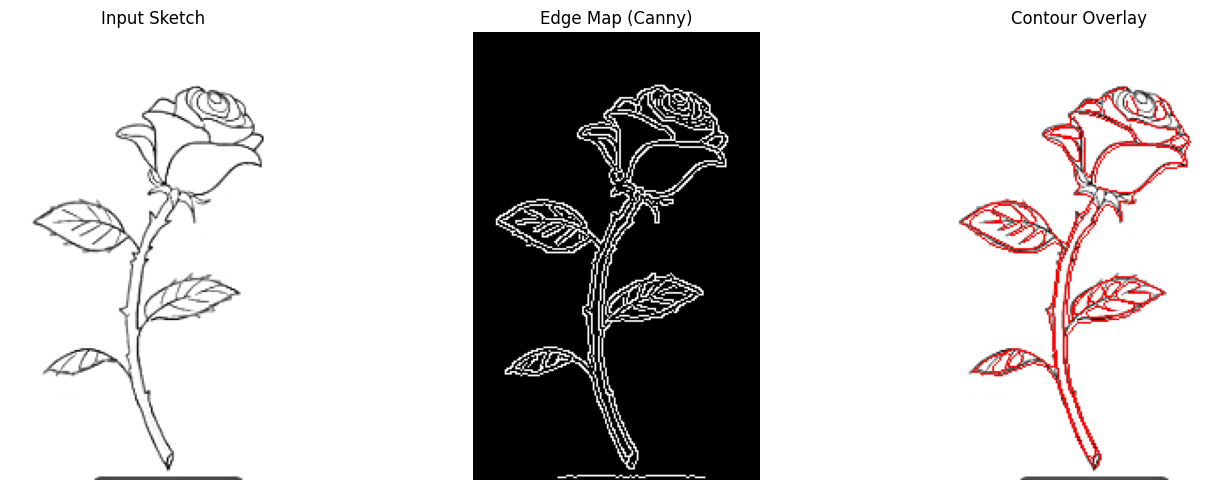

Semua output utama:
- image/output/structured/edge_map.npy
- image/output/structured/edge_map.png
- image/output/structured/contours_xy.json
- image/output/structured/svg_paths.json
- image/output/structured/sketch_paths.svg
- generated_code/redraw_with_matplotlib_opencv.py
- generated_code/redraw_with_turtle.py
- generated_code/render_svg_paths.html


In [18]:
# 7) Preview cepat hasil edge dan contour overlay
overlay = cv2.cvtColor(sketch_gray, cv2.COLOR_GRAY2BGR)
for c in contours_xy:
    pts = np.array(c, dtype=np.int32).reshape(-1, 1, 2)
    cv2.polylines(overlay, [pts], isClosed=False, color=(0, 0, 255), thickness=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sketch_gray, cmap='gray')
axes[0].set_title('Input Sketch')
axes[0].axis('off')

axes[1].imshow(edge_map, cmap='gray')
axes[1].set_title('Edge Map (Canny)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title('Contour Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print('Semua output utama:')
print('-', out_dir / 'edge_map.npy')
print('-', out_dir / 'edge_map.png')
print('-', out_dir / 'contours_xy.json')
print('-', out_dir / 'svg_paths.json')
print('-', out_dir / 'sketch_paths.svg')
print('-', code_dir / 'redraw_with_matplotlib_opencv.py')
print('-', code_dir / 'redraw_with_turtle.py')
print('-', code_dir / 'render_svg_paths.html')